
<a href="https://colab.research.google.com/github/ricomelgozajjesus/monografia-armonica/blob/main/python-lab/notebooks/Notebook_VII_01_mirada_estroboscopica_floquet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook VII.1 — Mirada estroboscópica y descomposición de Floquet

Este notebook acompaña la sección **Teoría de Floquet revisitada** de la monografía.

El objetivo es mostrar, con un ejemplo pequeño, cómo una dinámica lineal periódica puede observarse de dos maneras:

1. **Mirada intraperiódica:** se observa toda la trayectoria dentro de cada ciclo.
2. **Mirada estroboscópica:** se observan únicamente los estados separados por un período.

La idea central es que la dinámica observada de ciclo en ciclo puede ser reproducida por un sistema lineal invariante en el tiempo efectivo,

$$
\dot z = R z,
$$

si se escoge una matriz $R$ tal que

$$
e^{RT}=M,
$$

donde $M=\Phi(T)$ es la matriz de monodromía. Sin embargo, ese sistema efectivo no reproduce necesariamente la trayectoria dentro del período. La diferencia intraperiódica es precisamente lo que en Floquet queda representado por la matriz periódica $P(t)$.



## 1. Modelo: oscilador con rigidez periódica

Consideremos el oscilador lineal

$$
\ddot q + \left(\omega_0^2 + \epsilon \cos(\Omega t)
ight)q = 0.
$$

Aunque la ecuación es lineal en $q$, sus coeficientes dependen periódicamente del tiempo. Definimos

$$
x(t)=egin{bmatrix}q(t)\ \dot q(t)\end{bmatrix},
$$

y obtenemos el sistema de primer orden

$$
\dot x = A(t)x,
$$

con

$$
A(t)=
egin{bmatrix}
0 & 1\
-\omega_0^2-\epsilon\cos(\Omega t) & 0
\end{bmatrix}.
$$

El período de la modulación es

$$
T=
rac{2\pi}{\Omega}.
$$


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.linalg import logm, expm, eig

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

omega0 = 1.0
Omega = 1.0
epsilon = 0.35

T = 2*np.pi/Omega

print(f"omega0  = {omega0}")
print(f"Omega   = {Omega}")
print(f"epsilon = {epsilon}")
print(f"T       = {T:.6f}")


omega0  = 1.0
Omega   = 1.0
epsilon = 0.35
T       = 6.283185


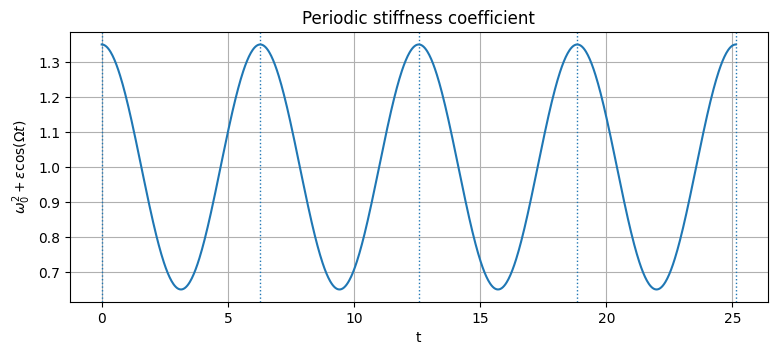

In [2]:

# ------------------------------------------------------------
# Periodic system matrix A(t)
# ------------------------------------------------------------

def A(t):
    return np.array([
        [0.0, 1.0],
        [-(omega0**2 + epsilon*np.cos(Omega*t)), 0.0]
    ])

# Plot the periodic coefficient omega0^2 + epsilon cos(Omega t)
t_plot = np.linspace(0, 4*T, 1000)
k_plot = omega0**2 + epsilon*np.cos(Omega*t_plot)

plt.figure(figsize=(9, 3.5))
plt.plot(t_plot, k_plot)
for k in range(5):
    plt.axvline(k*T, linestyle=":", linewidth=1)
plt.xlabel("t")
plt.ylabel(r"$\omega_0^2 + \epsilon\cos(\Omega t)$")
plt.title("Periodic stiffness coefficient")
plt.grid(True)
plt.show()



## 2. Matriz fundamental

La matriz fundamental satisface

$$
\dot\Phi(t)=A(t)\Phi(t),
\qquad
\Phi(0)=I.
$$

En dimensión dos, $\Phi(t)$ contiene en sus columnas la evolución de dos condiciones iniciales independientes:

$$
\Phi(0)=
egin{bmatrix}
1 & 0\
0 & 1
\end{bmatrix}.
$$

Al integrar $\Phi(t)$ hasta $T$, obtenemos la matriz de monodromía

$$
M=\Phi(T).
$$


In [4]:

# ------------------------------------------------------------
# Fundamental matrix integration
# ------------------------------------------------------------

def phi_rhs(t, y):
    Phi = y.reshape((2, 2))
    dPhi = A(t) @ Phi
    return dPhi.reshape(4)

Phi0 = np.eye(2).reshape(4)

n_periods = 4
t_span = (0.0, n_periods*T)
t_eval = np.linspace(t_span[0], t_span[1], 2401)

sol_phi = solve_ivp(
    phi_rhs,
    t_span,
    Phi0,
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

if not sol_phi.success:
    raise RuntimeError(sol_phi.message)

Phi_t = sol_phi.y.T.reshape((-1, 2, 2))
t = sol_phi.t

# Integrate exactly to one period to avoid selecting the nearest grid point.
sol_one_period = solve_ivp(
    phi_rhs,
    (0.0, T),
    Phi0,
    t_eval=[T],
    rtol=1e-11,
    atol=1e-13
)

M = sol_one_period.y[:, -1].reshape((2, 2))

print("Monodromy matrix M = Phi(T):")
print(M)
print("det(M) =", np.linalg.det(M))


Monodromy matrix M = Phi(T):
[[1.00256516 0.02548947]
 [0.20153021 1.00256516]]
det(M) = 0.9999999999867571



## 3. Multiplicadores de Floquet

Los valores propios de $M$ son los multiplicadores de Floquet:

$$
\mu_i = \lambda_i(M).
$$

Estos números describen la evolución ciclo a ciclo. Si $|\mu_i|<1$, la componente asociada decae de período en período; si $|\mu_i|>1$, crece; y si $|\mu_i|=1$, permanece marginal en escala estroboscópica.


In [6]:
# ------------------------------------------------------------
# Floquet multipliers
# ------------------------------------------------------------

multipliers, V = eig(M)

print("Floquet multipliers:")
for i, mu in enumerate(multipliers):
    print(f"mu_{i+1} = {mu}")

print("Magnitudes:")
for i, mu in enumerate(multipliers):
    print(f"|mu_{i+1}| = {abs(mu):.10f}")


Floquet multipliers:
mu_1 = (0.9308930061724423+0j)
mu_2 = (1.0742373112227606+0j)
Magnitudes:
|mu_1| = 0.9308930062
|mu_2| = 1.0742373112



## 4. Sistema efectivo estroboscópico

Buscamos una matriz constante $R$ tal que

$$
e^{RT}=M.
$$

Formalmente,

$$
R =
rac{1}{T}\log(M).
$$

Entonces el sistema LTI efectivo

$$
\dot z = Rz
$$

reproduce la misma evolución de período en período:

$$
z(kT)=M^k z(0).
$$

**Nota:** el logaritmo matricial no es único. La matriz $R$ depende de la rama seleccionada. Esta no unicidad anticipa la retícula espectral de Floquet.


In [8]:
# ------------------------------------------------------------
# Effective matrix R = log(M)/T
# ------------------------------------------------------------

R = logm(M)/T
R_display = np.real_if_close(R, tol=1000)

print("Effective matrix R = log(M)/T:")
print(R_display)

M_reconstructed = expm(R*T)
err_M = np.linalg.norm(M_reconstructed - M)

print("||exp(RT) - M|| =", err_M)


Effective matrix R = log(M)/T:
[[-1.05690605e-12  4.05330937e-03]
 [ 3.20471314e-02 -1.05076965e-12]]
||exp(RT) - M|| = 5.721958498152797e-17



## 5. Comparación: trayectoria periódica vs. trayectoria efectiva

Para una condición inicial $x_0$, la trayectoria real del sistema periódico es

$$
x(t)=\Phi(t)x_0.
$$

La trayectoria del sistema efectivo es

$$
z(t)=e^{Rt}x_0.
$$

Ambas coinciden en los instantes $0,T,2T,\ldots$, pero no necesariamente dentro de cada período.


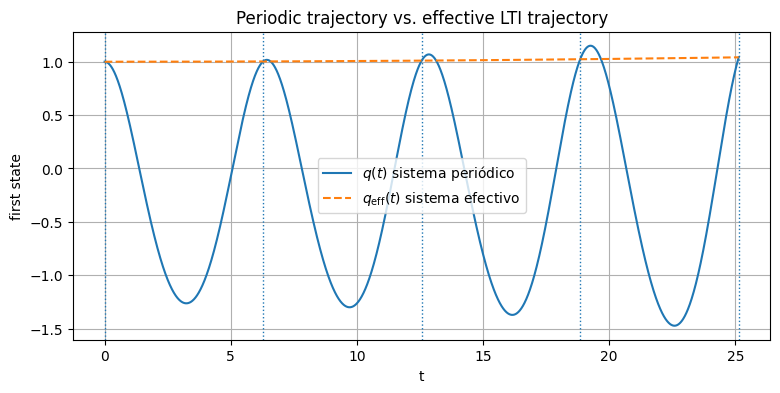

In [9]:

# ------------------------------------------------------------
# Compare real periodic trajectory x(t) and effective LTI z(t)
# ------------------------------------------------------------

x0 = np.array([1.0, 0.0])

x_t = np.einsum("tij,j->ti", Phi_t, x0)
z_t = np.array([expm(R*ti) @ x0 for ti in t])
z_t = np.real_if_close(z_t, tol=1000)

plt.figure(figsize=(9, 4))
plt.plot(t, x_t[:, 0], label=r"$q(t)$ sistema periódico")
plt.plot(t, z_t[:, 0], "--", label=r"$q_{\mathrm{eff}}(t)$ sistema efectivo")

for k in range(n_periods + 1):
    plt.axvline(k*T, linestyle=":", linewidth=1)

plt.xlabel("t")
plt.ylabel("first state")
plt.title("Periodic trajectory vs. effective LTI trajectory")
plt.legend()
plt.grid(True)
plt.show()


In [10]:

# ------------------------------------------------------------
# Stroboscopic comparison at multiples of T
# ------------------------------------------------------------

print("Stroboscopic comparison:")
for k in range(n_periods + 1):
    tk = k*T
    xk_periodic = np.linalg.matrix_power(M, k) @ x0
    xk_effective = expm(R*tk) @ x0
    diff = np.linalg.norm(xk_periodic - xk_effective)
    print(f"k={k}, t={tk:.4f}, ||x(kT)-z(kT)|| = {diff:.3e}")


Stroboscopic comparison:
k=0, t=0.0000, ||x(kT)-z(kT)|| = 0.000e+00
k=1, t=6.2832, ||x(kT)-z(kT)|| = 5.551e-17
k=2, t=12.5664, ||x(kT)-z(kT)|| = 2.483e-16
k=3, t=18.8496, ||x(kT)-z(kT)|| = 2.483e-16
k=4, t=25.1327, ||x(kT)-z(kT)|| = 5.979e-16



## 6. Reconstrucción de la parte periódica $P(t)$

La descomposición de Floquet afirma que

$$
\Phi(t)=P(t)e^{Rt}.
$$

Por tanto, una vez calculadas $\Phi(t)$ y $R$, podemos reconstruir

$$
P(t)=\Phi(t)e^{-Rt}.
$$

Esta matriz debe ser periódica:

$$
P(t+T)=P(t).
$$


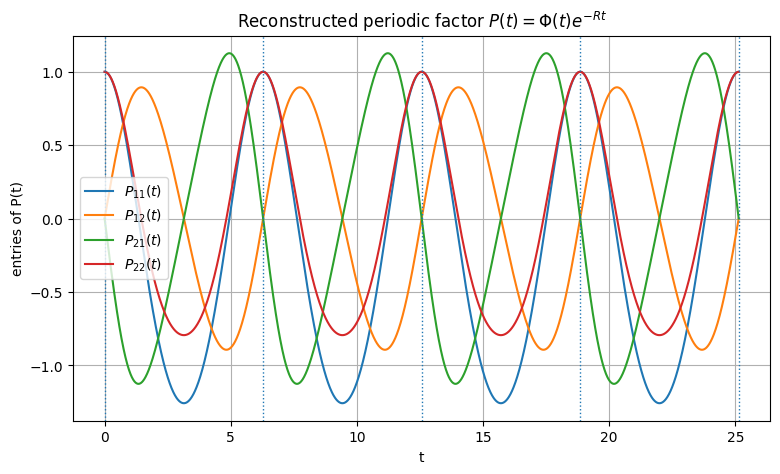

In [11]:

# ------------------------------------------------------------
# Reconstruct P(t) = Phi(t) exp(-Rt)
# ------------------------------------------------------------

P_t = np.array([Phi_t[i] @ expm(-R*t[i]) for i in range(len(t))])
P_t = np.real_if_close(P_t, tol=1000)

plt.figure(figsize=(9, 5))
plt.plot(t, P_t[:, 0, 0], label=r"$P_{11}(t)$")
plt.plot(t, P_t[:, 0, 1], label=r"$P_{12}(t)$")
plt.plot(t, P_t[:, 1, 0], label=r"$P_{21}(t)$")
plt.plot(t, P_t[:, 1, 1], label=r"$P_{22}(t)$")

for k in range(n_periods + 1):
    plt.axvline(k*T, linestyle=":", linewidth=1)

plt.xlabel("t")
plt.ylabel("entries of P(t)")
plt.title(r"Reconstructed periodic factor $P(t)=\Phi(t)e^{-Rt}$")
plt.legend()
plt.grid(True)
plt.show()


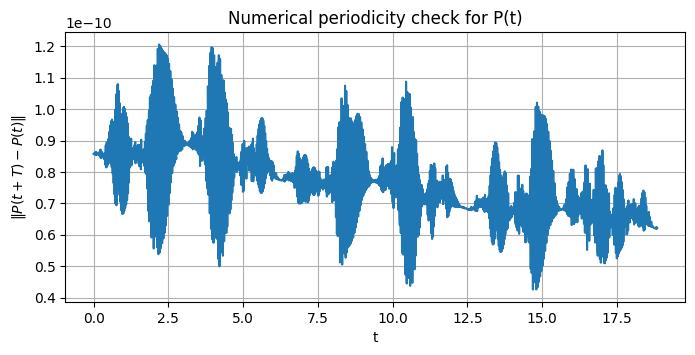

Max periodicity error: 1.2060454542876567e-10


In [12]:

# ------------------------------------------------------------
# Verify periodicity P(t + T) ≈ P(t)
# ------------------------------------------------------------

# The grid was chosen with n_periods equal segments, so this shift is exact in index count.
samples_per_period = (len(t) - 1) // n_periods

periodicity_errors = []
t_error = []

for i in range(len(t) - samples_per_period):
    err = np.linalg.norm(P_t[i + samples_per_period] - P_t[i])
    periodicity_errors.append(err)
    t_error.append(t[i])

periodicity_errors = np.array(periodicity_errors)
t_error = np.array(t_error)

plt.figure(figsize=(8, 3.5))
plt.plot(t_error, periodicity_errors)
plt.xlabel("t")
plt.ylabel(r"$\|P(t+T)-P(t)\|$")
plt.title("Numerical periodicity check for P(t)")
plt.grid(True)
plt.show()

print("Max periodicity error:", np.max(periodicity_errors))



## 7. Interpretación algebraica de la diferencia

La trayectoria real es

$$
x(t)=P(t)e^{Rt}x_0,
$$

mientras que la trayectoria efectiva es

$$
z(t)=e^{Rt}x_0.
$$

Por tanto,

$$
x(t)-z(t)=igl(P(t)-Iigr)e^{Rt}x_0.
$$

Esta ecuación mide lo que se pierde al mirar solo de manera estroboscópica. La matriz $R$ captura la huella acumulada del período; la matriz $P(t)$ conserva la coreografía intraperiódica.


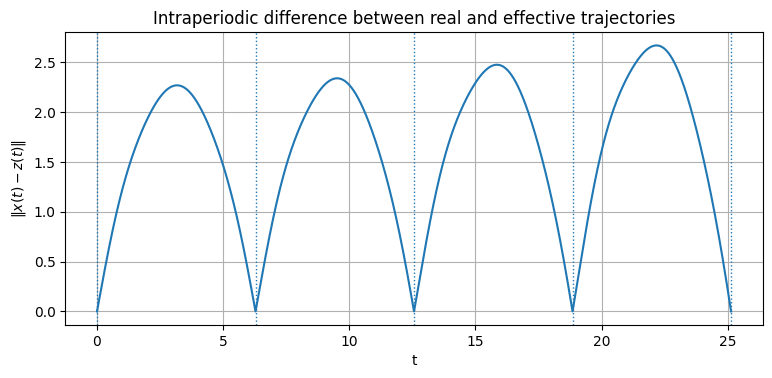

In [13]:

# ------------------------------------------------------------
# Difference between the periodic trajectory and effective trajectory
# ------------------------------------------------------------

diff_t = x_t - z_t
norm_diff = np.linalg.norm(diff_t, axis=1)

plt.figure(figsize=(9, 3.8))
plt.plot(t, norm_diff)
for k in range(n_periods + 1):
    plt.axvline(k*T, linestyle=":", linewidth=1)
plt.xlabel("t")
plt.ylabel(r"$\|x(t)-z(t)\|$")
plt.title("Intraperiodic difference between real and effective trajectories")
plt.grid(True)
plt.show()



## 8. Retícula espectral de Floquet

A partir de los multiplicadores $\mu_i$, los exponentes principales pueden escribirse como

$$

ho_i =
rac{1}{T}\log(\mu_i).
$$

Pero estos exponentes no son únicos, porque

$$

ho_i + j k \omega,
\qquad k\in\mathbb{Z},
$$

representa la misma familia de ramas, con

$$
\omega=
rac{2\pi}{T}.
$$

Esto produce la retícula espectral armónica.


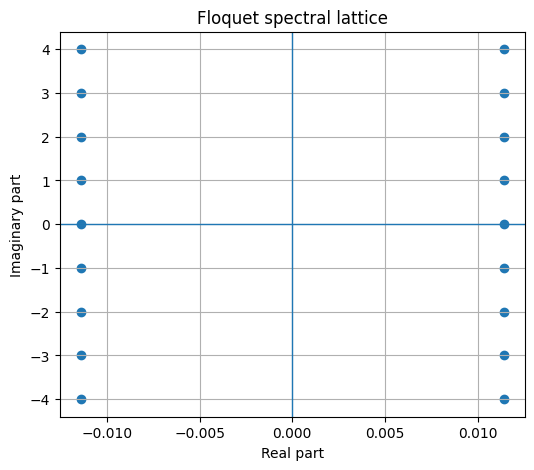

Principal Floquet exponents from scalar logarithm of multipliers:
rho_1 = (-0.011397233785251181+0j)
rho_2 = (0.011397233783143506+0j)


In [14]:

# ------------------------------------------------------------
# Floquet spectral lattice
# ------------------------------------------------------------

rho = np.log(multipliers)/T
omega = 2*np.pi/T

K = 4
lattice_points = []
labels = []

for i, r in enumerate(rho):
    for k in range(-K, K+1):
        lattice_points.append(r + 1j*k*omega)
        labels.append((i+1, k))

lattice_points = np.array(lattice_points)

plt.figure(figsize=(6, 5))
plt.scatter(lattice_points.real, lattice_points.imag)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("Floquet spectral lattice")
plt.grid(True)
plt.show()

print("Principal Floquet exponents from scalar logarithm of multipliers:")
for i, r in enumerate(rho):
    print(f"rho_{i+1} = {r}")



## 9. Conclusión

Este notebook muestra la cadena computacional básica de Floquet:

$$
A(t)
\longrightarrow
\Phi(t)
\longrightarrow
M=\Phi(T)
\longrightarrow
\mu_i
\longrightarrow
R=
rac{1}{T}\log(M)
\longrightarrow
P(t)=\Phi(t)e^{-Rt}.
$$

La comparación entre $x(t)$ y $z(t)$ muestra que la dinámica efectiva reproduce la evolución de ciclo en ciclo, pero no la modulación intraperiódica. Esa modulación queda separada y preservada por $P(t)$.
